In [183]:
import numpy as np
import matplotlib.pyplot as plt
import astropy
from matplotlib.colors import LogNorm
from numpy import log10
from scipy.optimize import curve_fit
from scipy import signal

In [184]:
data_soff = np.load('8_soff_1421_1pm-exactly.npz')

In [185]:
data_son = np.load('8_son_1420_1pm-exactly.npz')

First, graph the data by itself without editing for son, soff, and soff/son

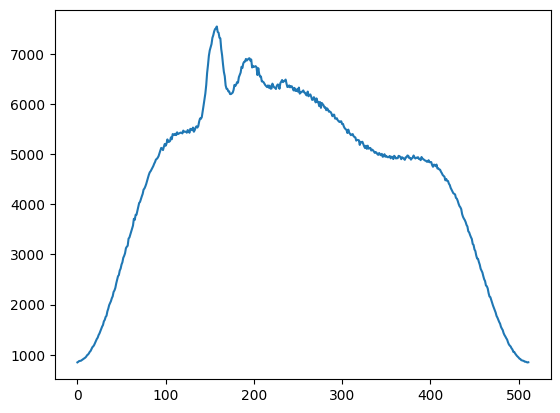

In [186]:
x_soff = data_soff['data']
fs_soff = 1.4204058e9
x_soff-=x_soff.mean()
x_soff.shape=(-1,512)
#f,P=power_spectrum(x,fs)
P_soff=np.abs(np.fft.fft(x_soff))**2
p_soff = np.mean(P_soff,axis=0)
plt.plot(np.fft.fftshift(p_soff))

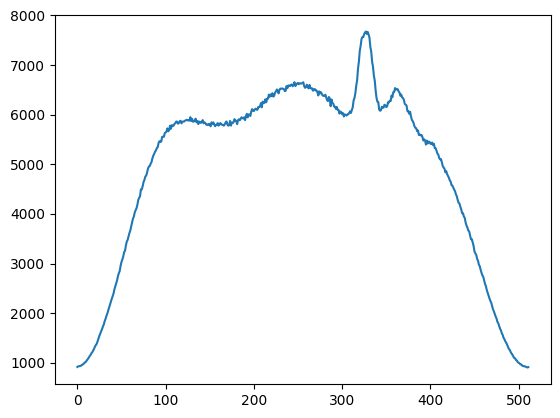

In [187]:
x_son = data_son['data']
fs_son = 1.4204058e9
x_son-=x_son.mean()
x_son.shape=(-1,512)
#f,P=power_spectrum(x,fs)
P_son=np.abs(np.fft.fft(x_son))**2
p_son = np.mean(P_son,axis=0)
plt.plot(np.fft.fftshift(p_son))

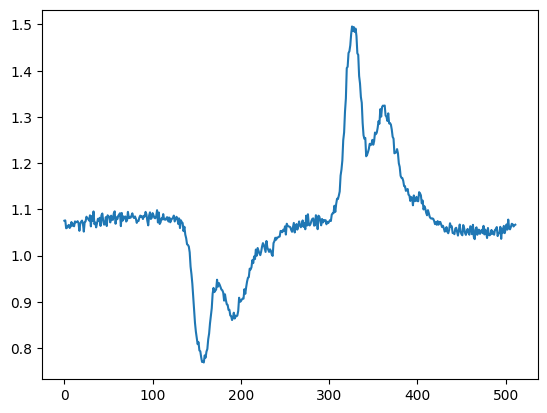

In [188]:
plt.plot(np.fft.fftshift(p_son)/np.fft.fftshift(p_soff))

Now, make sure that the axis are correctly scaled and labeled

Text(0, 0.5, 'Power (unknown units)')

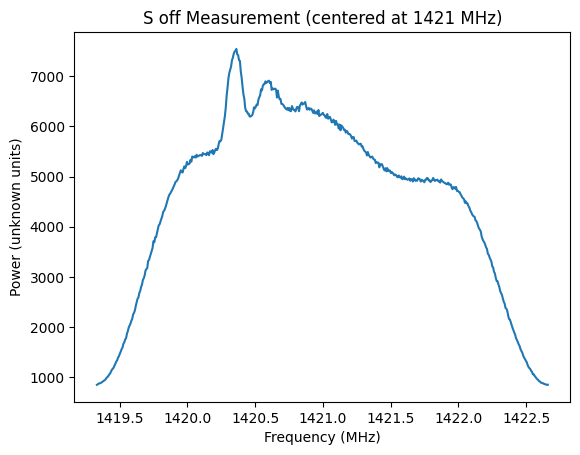

In [189]:
x_soff = data_soff['data']
fs_soff = 1.4204058e9
x_soff-=x_soff.mean()
x_soff.shape=(-1,512)
#f,P=power_spectrum(x,fs)
P_soff=np.abs(np.fft.fft(x_soff))**2
p_soff = np.mean(P_soff,axis=0)

#Nsm_soff = 8  
#ker_soff = np.ones(Nsm_soff)/Nsm_soff
#p_sm_soff = np.convolve(p_soff, ker_soff, mode="same")
x_soff = []
for i in range(len(p_soff)):
    x_soff.append(((i-256)/(0.3*512)) + 1421)

plt.plot(x_soff, np.fft.fftshift(p_soff))
plt.title('S off Measurement (centered at 1421 MHz)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power (unknown units)')

Text(0, 0.5, 'Power (unknown units)')

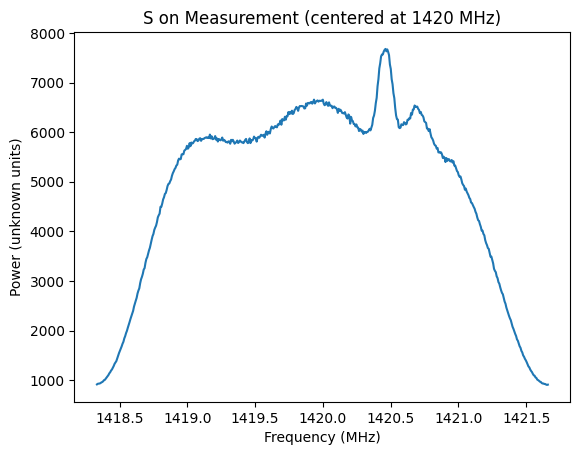

In [190]:
x_son = data_son['data']
fs_son = 1.4204058e9
x_son-=x_son.mean()
x_son.shape=(-1,512)
#f,P=power_spectrum(x,fs)
P_son=np.abs(np.fft.fft(x_son))**2
p_son = np.mean(P_son,axis=0)

#Nsm_son = 8  
#ker_son = np.ones(Nsm_son)/Nsm_son
#p_sm_son = np.convolve(p_son, ker_son, mode="same")
x_son = []
for i in range(len(p_son)):
    x_son.append(((i-256)/(0.3*512)) + 1420)

plt.plot(x_son, np.fft.fftshift(p_son))
plt.title('S on Measurement (centered at 1420 MHz)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Power (unknown units)')

Text(0, 0.5, 'Power (unknown units)')

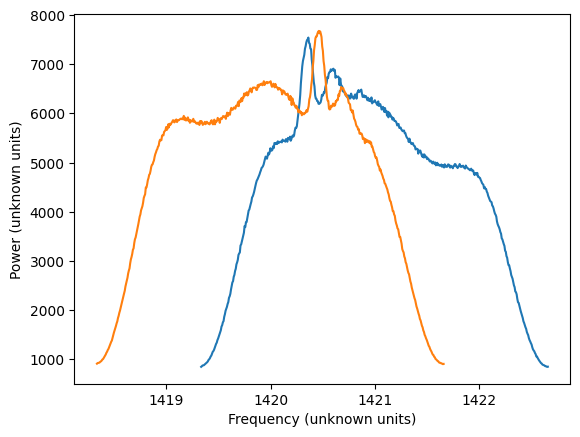

In [191]:
plt.plot(x_soff, np.fft.fftshift(p_soff))
plt.plot(x_son, np.fft.fftshift(p_son))
plt.xlabel('Frequency (unknown units)')
plt.ylabel('Power (unknown units)')

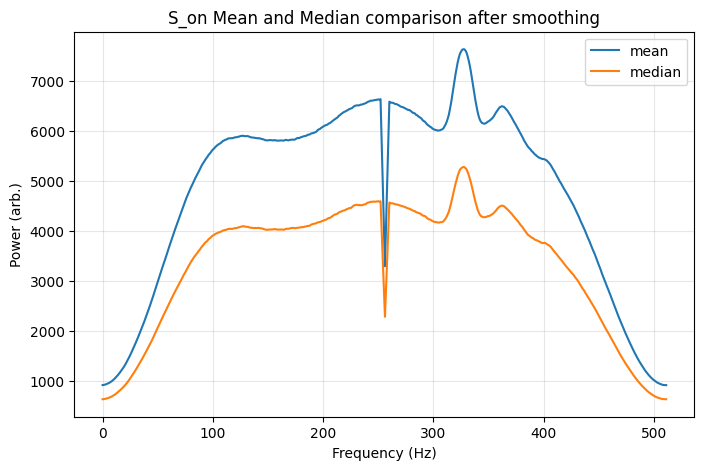

In [192]:
#smooth of s_on
x_son = data_son['data']
x_son-=x_son.mean()
x_son.shape=(-1,512)
#f,P=power_spectrum(x,fs)
P=np.abs(np.fft.fft(x_son))**2
p = np.mean(P,axis=0)
p_median = np.median(P,axis=0)
# --- smoothing (boxcar moving average) ---
Nsm = 8  # try 5, 9, 15... bigger = smoother (lower resolution)
ker = np.ones(Nsm)/Nsm
p_sm = np.convolve(p, ker, mode="same")
p_median_sm = np.convolve(p_median, ker, mode="same")

plt.figure(figsize = (8,5))
# plt.subplots_adjust(left = .2, bottom = .15, right = .95, top = .9)
plt.plot(np.fft.fftshift(p_sm), label="mean")
plt.plot(np.fft.fftshift(p_median_sm), label="median")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (arb.)")
plt.title("S_on Mean and Median comparison after smoothing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

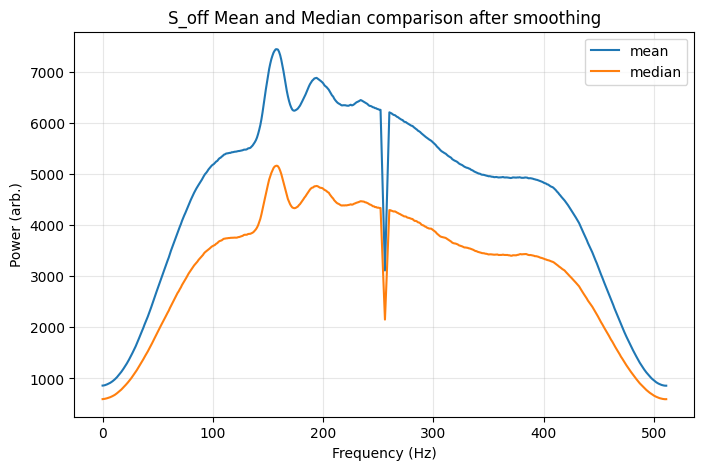

In [193]:
#smooth of s_off
x_soff = data_soff['data']
x_soff-=x_soff.mean()
x_soff.shape=(-1,512)
#f,P=power_spectrum(x,fs)
P=np.abs(np.fft.fft(x_soff))**2
p = np.mean(P,axis=0)
p_median = np.median(P,axis=0)
# --- smoothing (boxcar moving average) ---
Nsm = 8  # try 5, 9, 15... bigger = smoother (lower resolution)
ker = np.ones(Nsm)/Nsm
p_sm = np.convolve(p, ker, mode="same")
p_median_sm = np.convolve(p_median, ker, mode="same")

plt.figure(figsize = (8,5))
# plt.subplots_adjust(left = .2, bottom = .15, right = .95, top = .9)
plt.plot(np.fft.fftshift(p_sm), label="mean")
plt.plot(np.fft.fftshift(p_median_sm), label="median")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (arb.)")
plt.title("S_off Mean and Median comparison after smoothing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

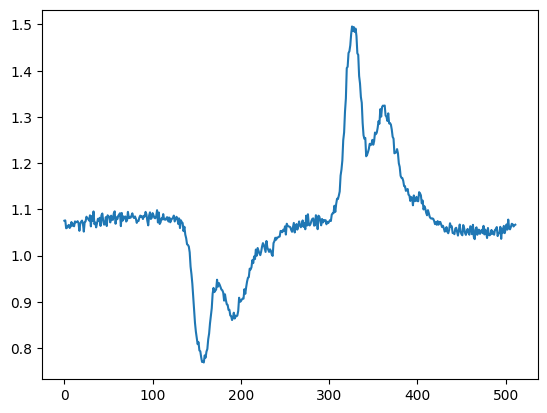

In [194]:
plt.plot(np.fft.fftshift(p_son)/np.fft.fftshift(p_soff))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


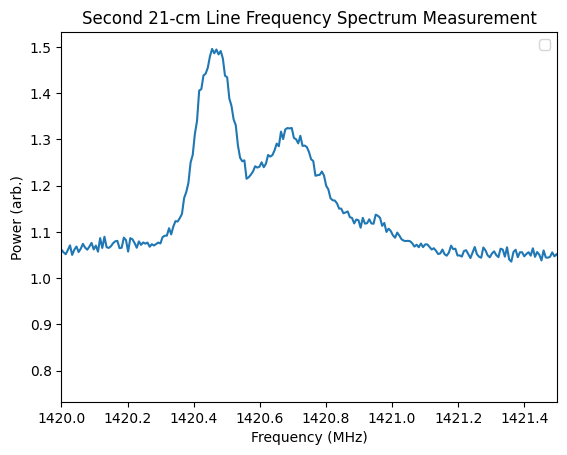

In [195]:
x = []
for i in range(len(p_soff)):
    x.append(((i-256)/(0.3*512)) + 1420)
plt.plot(x, np.fft.fftshift(p_son)/np.fft.fftshift(p_soff))
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (arb.)")
plt.title("Second 21-cm Line Frequency Spectrum Measurement")
plt.xlim(1420, 1421.5)
plt.legend()



In [196]:
x_2 = []
y_2 = []

for i in range(len(p_soff)):
    if i >256:
        x_2.append(((i-256)/(0.3*512)) + 1420)
        y_2.append((np.fft.fftshift(p_son)/np.fft.fftshift(p_soff))[i])
    
print(x_2)
print(y_2)

[1420.0065104166667, 1420.0130208333333, 1420.01953125, 1420.0260416666667, 1420.0325520833333, 1420.0390625, 1420.0455729166667, 1420.0520833333333, 1420.05859375, 1420.0651041666667, 1420.0716145833333, 1420.078125, 1420.0846354166667, 1420.0911458333333, 1420.09765625, 1420.1041666666667, 1420.1106770833333, 1420.1171875, 1420.1236979166667, 1420.1302083333333, 1420.13671875, 1420.1432291666667, 1420.1497395833333, 1420.15625, 1420.1627604166667, 1420.1692708333333, 1420.17578125, 1420.1822916666667, 1420.1888020833333, 1420.1953125, 1420.2018229166667, 1420.2083333333333, 1420.21484375, 1420.2213541666667, 1420.2278645833333, 1420.234375, 1420.2408854166667, 1420.2473958333333, 1420.25390625, 1420.2604166666667, 1420.2669270833333, 1420.2734375, 1420.2799479166667, 1420.2864583333333, 1420.29296875, 1420.2994791666667, 1420.3059895833333, 1420.3125, 1420.3190104166667, 1420.3255208333333, 1420.33203125, 1420.3385416666667, 1420.3450520833333, 1420.3515625, 1420.3580729166667, 1420.

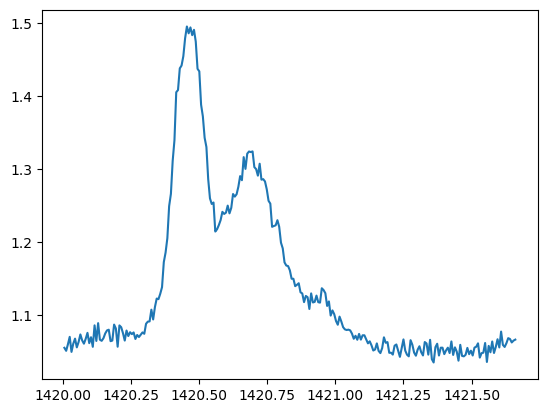

In [197]:
plt.plot(x_2, y_2)

In [198]:
import gauss as gs

In [ ]:
#ans2 = gs.gaussfit(x_2, y_2, amp=[20,20], avg=[1420.4,1420.7], sig=[1,1])
#profile2 = gs.gaussval(x_2, **ans2)

c:\Users\griff\Documents\astro_121\Lab_2\gauss.py:41: OptimizeWarning: Covariance of the parameters could not be estimated
  prms, prm_covariance = curve_fit(_gauss, x, y, p0=prms0)


In [ ]:
#chisq = np.sum(np.abs(y_2 - profile2)**2)
#print(f'Chi-Square: {chisq}')
#chisq_r = np.sum(np.abs(y_2 - profile2)**2 / 1**2) / (len(x_2) - 6)
#print(f'Reduced Chi-Square: {chisq_r}')

Chi-Square: 333.3212976198847
Reduced Chi-Square: 1.3386397494774487


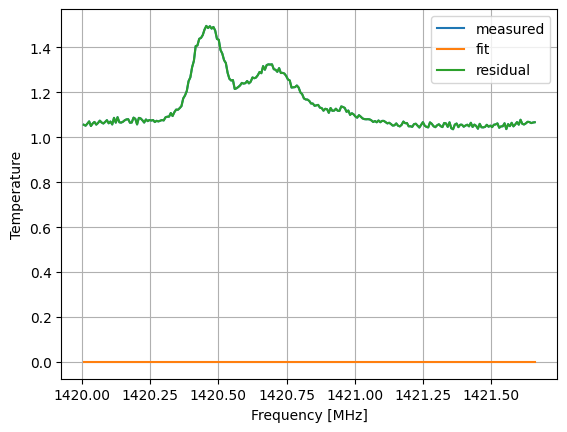

In [ ]:
#plt.figure()
#plt.plot(x_2, y_2, label='measured')
#plt.plot(x_2, profile2, label='fit')
#plt.plot(x_2, y_2 - profile2, label='residual')
#plt.xlabel('Frequency [MHz]')
#plt.ylabel('Temperature')
#plt.legend()
#_ = plt.grid()

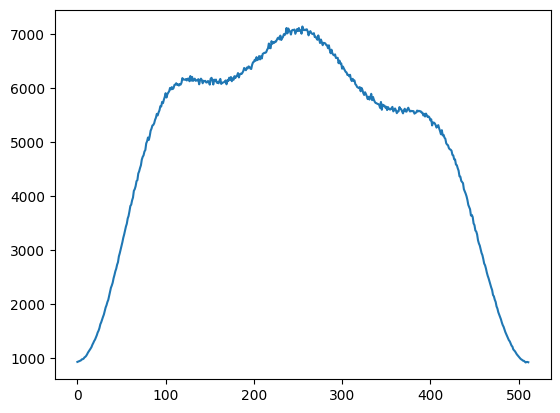

In [202]:
data = np.load('8_soff_1418.npz')
x = data['data']
fs = 1.4204058e9
x-=x.mean()
x.shape=(-1,512)
#f,P=power_spectrum(x,fs)
P=np.abs(np.fft.fft(x))**2
p = np.mean(P,axis=0)
plt.plot(np.fft.fftshift(p))

The best data that I got was when S_on was the 1420MHz measuement, where the spikes were within the band, and S_off was the 1418MHz where the peaks did not show up at all. There is a chance that we need to do this with two different datasets where the spikes appear in both (e.g. 1420 and 1421 MHz), however that gave much more confusing data.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


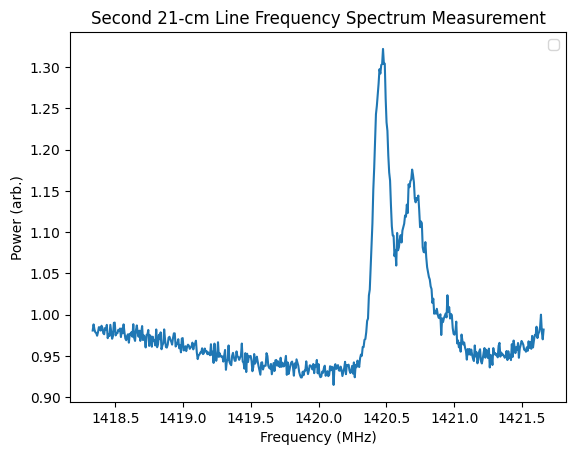

In [203]:
x_soff = []
for i in range(len(p_soff)):
    x_soff.append(((i-256)/(0.3*512)) + 1420)
#plt.plot(x_soff, np.fft.fftshift(p_son)/np.fft.fftshift(p_soff))
plt.plot(x_soff, (np.fft.fftshift(p_son)/np.fft.fftshift(p)))
#plt.xlim(1420.406-1.0, 1420.406+1.0)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (arb.)")
plt.title("Second 21-cm Line Frequency Spectrum Measurement")
plt.legend()


In [207]:
print(type(x_soff))

<class 'list'>


In [220]:
x_soff = np.array(x_soff)
power1 = np.array(np.fft.fftshift(p_son)/np.fft.fftshift(p))

In [226]:
print(x_soff)
#print(power1)

[1418.33333333 1418.33984375 1418.34635417 1418.35286458 1418.359375
 1418.36588542 1418.37239583 1418.37890625 1418.38541667 1418.39192708
 1418.3984375  1418.40494792 1418.41145833 1418.41796875 1418.42447917
 1418.43098958 1418.4375     1418.44401042 1418.45052083 1418.45703125
 1418.46354167 1418.47005208 1418.4765625  1418.48307292 1418.48958333
 1418.49609375 1418.50260417 1418.50911458 1418.515625   1418.52213542
 1418.52864583 1418.53515625 1418.54166667 1418.54817708 1418.5546875
 1418.56119792 1418.56770833 1418.57421875 1418.58072917 1418.58723958
 1418.59375    1418.60026042 1418.60677083 1418.61328125 1418.61979167
 1418.62630208 1418.6328125  1418.63932292 1418.64583333 1418.65234375
 1418.65885417 1418.66536458 1418.671875   1418.67838542 1418.68489583
 1418.69140625 1418.69791667 1418.70442708 1418.7109375  1418.71744792
 1418.72395833 1418.73046875 1418.73697917 1418.74348958 1418.75
 1418.75651042 1418.76302083 1418.76953125 1418.77604167 1418.78255208
 1418.7890625  

In [255]:
mask = (x_soff < 1420.2) | (x_soff > 1421.25)
frequency = x_soff[mask]
power = power1[mask]
degree = 3



In [249]:
print(len(frequency))
print(len(power))

350
350


To fit the graph to a polynomial to correct the data, we can fist mask the data so that we are only fitting the polynomial to the ends of the data, then you can keep increasing the degree until the polynomial line looks the most accurate.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


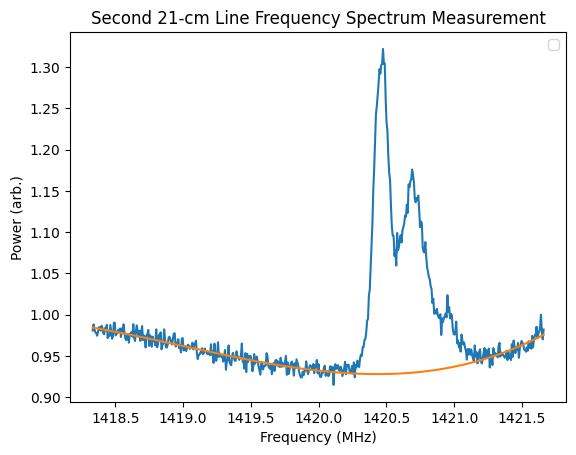

In [256]:
coefficients = np.polyfit(frequency, power, degree)
curvefit = np.polyval(coefficients, x_soff)

plt.plot(x_soff, (np.fft.fftshift(p_son)/np.fft.fftshift(p)))
plt.plot(x_soff, curvefit)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (arb.)")
plt.title("Second 21-cm Line Frequency Spectrum Measurement")
plt.legend()

In [275]:
power2 = np.array((np.fft.fftshift(p_son)/np.fft.fftshift(p))-curvefit)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


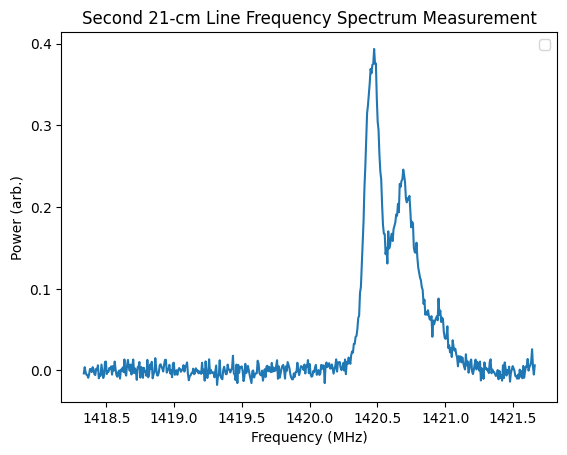

In [276]:
plt.plot(x_soff, power2)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (arb.)")
plt.title("Second 21-cm Line Frequency Spectrum Measurement")
plt.legend()

Now, plot the Gaussians

In [279]:
ans1 = gs.gaussfit(x_soff, power2, amp=0.2, avg=1420.5, sig=1)
profile1 = gs.gaussval(x_soff, **ans1)

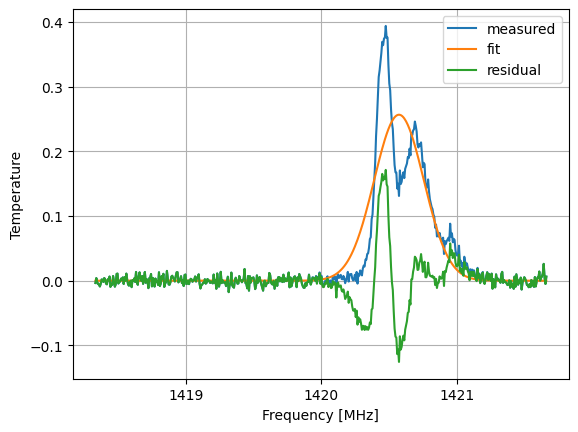

In [280]:
plt.figure()
plt.plot(x_soff, power2, label='measured')
plt.plot(x_soff, profile1, label='fit')
plt.plot(x_soff, power2 - profile1, label='residual')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Temperature')
plt.xticks([1419, 1420, 1421])
plt.legend()
_ = plt.grid()

In [274]:
SIZE = 10000
TSYS = 1
noise = TSYS * np.random.normal(size=SIZE)

In [363]:
ans2 = gs.gaussfit(x_soff, power2, amp=[0.2,0.2], avg=[1420.4,1420.7], sig=[0.8,1.2])
profile2 = gs.gaussval(x_soff, **ans2)
print(ans2)

{'amp': array([0.3247585 , 0.19930768]), 'avg': array([1420.4560849 , 1420.68317226]), 'sig': array([0.04776577, 0.1500936 ])}


Take the coefficients given by pointing ans2 above and replace them into ans2

In [364]:
ans2 = gs.gaussfit(x_soff, power2, amp=[0.3247585 , 0.19930768], avg=[1420.4560849 , 1420.68317226], sig=[0.04776577, 0.1500936 ])
profile2 = gs.gaussval(x_soff, **ans2)

In [365]:
chisq = np.sum(np.abs(power2 - profile2)**2)
print(f'Chi-Square: {chisq}')
chisq_r = np.sum(np.abs(power2 - profile2)**2 / TSYS**2) / (x_soff.size - 6)
print(f'Reduced Chi-Square: {chisq_r}')

Chi-Square: 0.06397104537272495
Reduced Chi-Square: 0.00012642499085518765


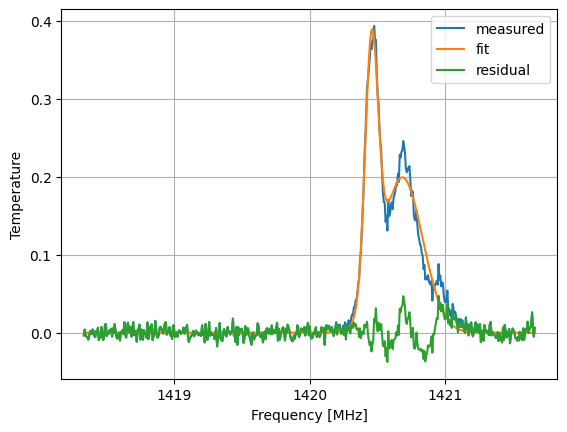

In [366]:
plt.figure()
plt.plot(x_soff, power2, label='measured')
plt.plot(x_soff, profile2, label='fit')
plt.plot(x_soff, power2 - profile2, label='residual')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Temperature')
plt.xticks([1419, 1420, 1421])
plt.legend()
_ = plt.grid()

Future Steps: the residuals are not perfect and there seems to be a third spike, so we can  potentiall map to a 3rd or even 4th gaussian. WE do this by plugging in the coefficients we got for the first 2 gaussians, trying similiar values for the third gausian, then replaceing with the new coefficients.

In [367]:
ans3 = gs.gaussfit(x_soff, power2, amp=[0.3247585 , 0.19930768,0.2], avg=[1420.4560849 , 1420.68317226,1420.8], sig=[0.04776577, 0.1500936,1.0])
profile3 = gs.gaussval(x_soff, **ans3)
print(ans3)
#ans4 = gs.gaussfit(x_soff, power2, amp=[-8.27804282e-02,  2.56577318e-01, -1.44359476e-04], avg=[1422.31265142, 1420.57289205, 1415.35090551], sig=[ 3.35081769e-02, -1.83145492e-01, -1.69093300e+03])
#profile3 = gs.gaussval(x_soff, **ans4)

{'amp': array([0.34724959, 0.1411955 , 0.09041653]), 'avg': array([1420.46168051, 1420.68581256, 1420.73384976]), 'sig': array([0.05223448, 0.07135722, 0.20897133])}


In [370]:
ans3 = gs.gaussfit(x_soff, power2, amp=[0.34724959, 0.1411955 , 0.09041653], avg=[1420.46168051, 1420.68581256, 1420.73384976], sig=[0.05223448, 0.07135722, 0.20897133])
profile3 = gs.gaussval(x_soff, **ans3)

In [371]:
chisq = np.sum(np.abs(power2 - profile3)**2)
print(f'Chi-Square: {chisq}')
chisq_r = np.sum(np.abs(power2 - profile3)**2 / TSYS**2) / (x_soff.size - 6)
print(f'Reduced Chi-Square: {chisq_r}')

Chi-Square: 0.030089029773122045
Reduced Chi-Square: 5.94644857176325e-05


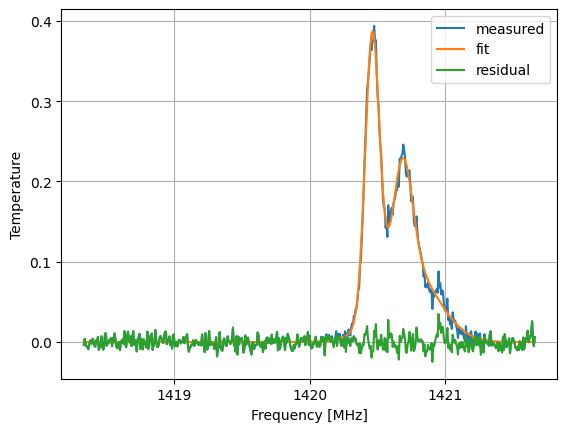

In [372]:
plt.figure()
plt.plot(x_soff, power2, label='measured')
plt.plot(x_soff, profile3, label='fit')
plt.plot(x_soff, power2 - profile3, label='residual')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Temperature')
plt.xticks([1419, 1420, 1421])
plt.legend()
_ = plt.grid()

In [373]:
ans4 = gs.gaussfit(x_soff, power2, amp=[0.34724959, 0.1411955 , 0.09041653, 0.8], avg=[1420.46168051, 1420.68581256, 1420.73384976, 1420.8], sig=[0.05223448, 0.07135722, 0.20897133, 0.2])
profile4 = gs.gaussval(x_soff, **ans4)
print(ans4)


{'amp': array([ 0.37509626,  0.22675299, -0.00894219,  0.05671478]), 'avg': array([1420.46123783, 1420.69067078, 1420.01512959, 1420.94955731]), 'sig': array([ 0.05460615,  0.09150063, -0.0055193 ,  0.08846062])}


In [374]:
ans4 = gs.gaussfit(x_soff, power2, amp=[0.37509626,  0.22675299, -0.00894219,  0.05671478], avg=[1420.46123783, 1420.69067078, 1420.01512959, 1420.94955731], sig=[0.05460615,  0.09150063, -0.0055193 ,  0.08846062])
profile4 = gs.gaussval(x_soff, **ans4)

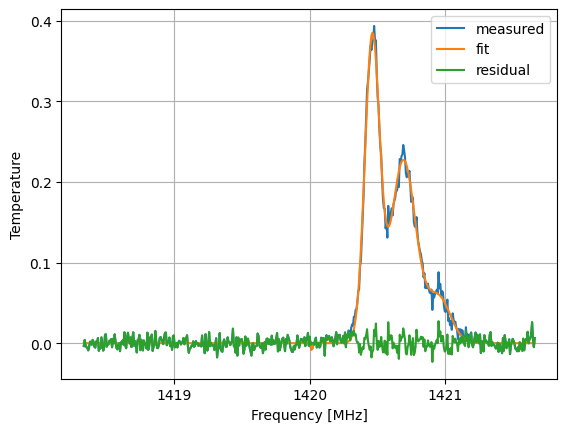

In [375]:
plt.figure()
plt.plot(x_soff, power2, label='measured')
plt.plot(x_soff, profile4, label='fit')
plt.plot(x_soff, power2 - profile4, label='residual')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Temperature')
plt.xticks([1419, 1420, 1421])
plt.legend()
_ = plt.grid()

We can repeat this process as many times as we want in order for our residuals to appear line noise, byt the current residuals look good enough to use.

In [376]:
chisq = np.sum(np.abs(power2 - profile4)**2)
print(f'Chi-Square: {chisq}')
chisq_r = np.sum(np.abs(power2 - profile4)**2 / TSYS**2) / (x_soff.size - 6)
print(f'Reduced Chi-Square: {chisq_r}')

Chi-Square: 0.029078600030229457
Reduced Chi-Square: 5.7467588992548334e-05


To get a more accurate redused chi-squared value, you can change the TSYS variable to the temperature of the hydrogen line that we determine in earlier parts of the lab.

Now, we can change the x coordinates in order to find the blue/redshift via the formula ((frequency observed - frequency emitted)/(frequency emitted)) times c.

In [380]:
x_final = ((-1420.4058+x_soff)/x_soff) * (3*10^8)

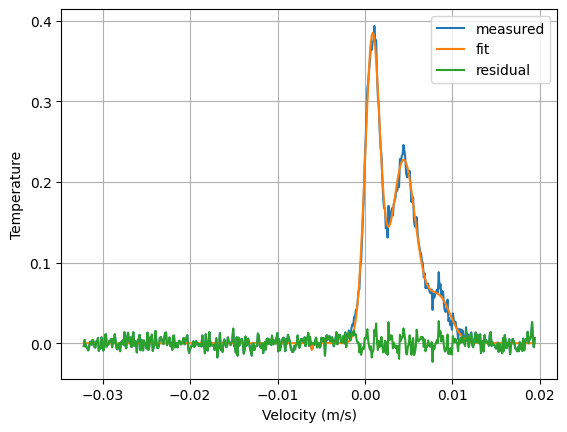

In [381]:
plt.figure()
plt.plot(x_final, power2, label='measured')
plt.plot(x_final, profile4, label='fit')
plt.plot(x_final, power2 - profile4, label='residual')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Temperature')
plt.legend()
_ = plt.grid()

Since most of our spikes have positive velocities, that means that we have blueshift and the observed hydrogen is moving away from us. We can determine the exact blueshift given the coefficients we got from plotting the gaussians.